In [1]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parent
TEST_PATH = PROJECT_ROOT / "data" / "raw" / "test_data.csv"

print("Project root:", PROJECT_ROOT)
print("Test path:", TEST_PATH)
print("Exists:", TEST_PATH.exists())

df = pd.read_csv(TEST_PATH)
print(df.shape)
df.head()

Project root: /home/jacobhardy/capstone
Test path: /home/jacobhardy/capstone/data/raw/test_data.csv
Exists: True
(13657, 11)


,MMSI,voyage_id,num_pings,row_id,TIME,LAT,LON,SPEED,COG,HEADING,dt
0,205089000,1_205089000,13,1_205089000_1,2023-03-01 06:55:00,22.029460,-77.311284,13.6,109.1,107.0,300.0
1,205089000,1_205089000,13,1_205089000_2,2023-03-01 07:15:00,22.006908,-77.235489,13.4,108.3,107.0,1200.0
2,205089000,1_205089000,13,1_205089000_3,2023-03-01 07:20:00,21.999225,-77.208927,13.4,106.0,106.0,300.0
3,205089000,1_205089000,13,1_205089000_4,2023-03-01 07:30:00,21.989461,-77.173879,13.4,106.8,107.0,600.0
4,205089000,1_205089000,13,1_205089000_5,2023-03-01 07:35:00,21.981135,-77.144347,13.4,107.1,107.0,300.0


In [3]:
required_cols = [
    "MMSI",
    "voyage_id",
    "TIME",
    "LAT",
    "LON",
    "SPEED",
    "COG",
    "dt",
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

dr_df = df[required_cols].copy()

dr_df["MMSI"] = dr_df["MMSI"].astype(str)
dr_df["voyage_id"] = dr_df["voyage_id"].astype(str)
dr_df["TIME"] = pd.to_datetime(dr_df["TIME"], errors="coerce")

for col in ["LAT", "LON", "SPEED", "COG", "dt"]:
    dr_df[col] = pd.to_numeric(dr_df[col], errors="coerce")

dr_df = dr_df.dropna(subset=required_cols).copy()
dr_df = dr_df.sort_values(["MMSI", "voyage_id", "TIME"]).reset_index(drop=True)

print(dr_df.shape)
dr_df.head()

(13657, 8)


,MMSI,voyage_id,TIME,LAT,LON,SPEED,COG,dt
0,205089000,1_205089000,2023-03-01 06:55:00,22.029460,-77.311284,13.6,109.1,300.0
1,205089000,1_205089000,2023-03-01 07:15:00,22.006908,-77.235489,13.4,108.3,1200.0
2,205089000,1_205089000,2023-03-01 07:20:00,21.999225,-77.208927,13.4,106.0,300.0
3,205089000,1_205089000,2023-03-01 07:30:00,21.989461,-77.173879,13.4,106.8,600.0
4,205089000,1_205089000,2023-03-01 07:35:00,21.981135,-77.144347,13.4,107.1,300.0


In [4]:
EARTH_RADIUS_M = 6_371_000.0
KNOT_TO_MPS = 0.514444

def knots_to_mps(speed_knots):
    return speed_knots * KNOT_TO_MPS

def dead_reckon_point(lat_deg, lon_deg, speed_knots, cog_deg, dt_seconds):
    """
    Predict next position from current position using dead reckoning.
    Inputs:
        lat_deg, lon_deg : current position in degrees
        speed_knots      : speed over ground in knots
        cog_deg          : course over ground in degrees
        dt_seconds       : elapsed time in seconds
    Returns:
        pred_lat_deg, pred_lon_deg
    """
    distance_m = knots_to_mps(speed_knots) * dt_seconds

    lat1 = math.radians(lat_deg)
    lon1 = math.radians(lon_deg)
    bearing = math.radians(cog_deg)

    angular_distance = distance_m / EARTH_RADIUS_M

    lat2 = math.asin(
        math.sin(lat1) * math.cos(angular_distance) +
        math.cos(lat1) * math.sin(angular_distance) * math.cos(bearing)
    )

    lon2 = lon1 + math.atan2(
        math.sin(bearing) * math.sin(angular_distance) * math.cos(lat1),
        math.cos(angular_distance) - math.sin(lat1) * math.sin(lat2)
    )

    return math.degrees(lat2), math.degrees(lon2)

def haversine_m(lat1, lon1, lat2, lon2, R=EARTH_RADIUS_M):
    lat1 = np.deg2rad(lat1)
    lon1 = np.deg2rad(lon1)
    lat2 = np.deg2rad(lat2)
    lon2 = np.deg2rad(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2.0 * np.arcsin(np.sqrt(a))
    return R * c

In [5]:
dr_pairs = dr_df.copy()

dr_pairs["next_MMSI"] = dr_pairs["MMSI"].shift(-1)
dr_pairs["next_voyage_id"] = dr_pairs["voyage_id"].shift(-1)
dr_pairs["next_TIME"] = dr_pairs["TIME"].shift(-1)
dr_pairs["next_LAT"] = dr_pairs["LAT"].shift(-1)
dr_pairs["next_LON"] = dr_pairs["LON"].shift(-1)

same_track_mask = (
    (dr_pairs["MMSI"] == dr_pairs["next_MMSI"]) &
    (dr_pairs["voyage_id"] == dr_pairs["next_voyage_id"])
)

dr_pairs = dr_pairs[same_track_mask].copy().reset_index(drop=True)

print("Number of applicable DR pairs:", len(dr_pairs))
dr_pairs.head()

Number of applicable DR pairs: 12841


,MMSI,voyage_id,TIME,LAT,LON,SPEED,COG,dt,next_MMSI,next_voyage_id,next_TIME,next_LAT,next_LON
0,205089000,1_205089000,2023-03-01 06:55:00,22.029460,-77.311284,13.6,109.1,300.0,205089000,1_205089000,2023-03-01 07:15:00,22.006908,-77.235489
1,205089000,1_205089000,2023-03-01 07:15:00,22.006908,-77.235489,13.4,108.3,1200.0,205089000,1_205089000,2023-03-01 07:20:00,21.999225,-77.208927
2,205089000,1_205089000,2023-03-01 07:20:00,21.999225,-77.208927,13.4,106.0,300.0,205089000,1_205089000,2023-03-01 07:30:00,21.989461,-77.173879
3,205089000,1_205089000,2023-03-01 07:30:00,21.989461,-77.173879,13.4,106.8,600.0,205089000,1_205089000,2023-03-01 07:35:00,21.981135,-77.144347
4,205089000,1_205089000,2023-03-01 07:35:00,21.981135,-77.144347,13.4,107.1,300.0,205089000,1_205089000,2023-03-01 08:05:00,21.941281,-77.031069


In [6]:
dr_pairs = dr_df.copy()

dr_pairs["next_MMSI"] = dr_pairs["MMSI"].shift(-1)
dr_pairs["next_voyage_id"] = dr_pairs["voyage_id"].shift(-1)
dr_pairs["next_TIME"] = dr_pairs["TIME"].shift(-1)
dr_pairs["next_LAT"] = dr_pairs["LAT"].shift(-1)
dr_pairs["next_LON"] = dr_pairs["LON"].shift(-1)

same_track_mask = (
    (dr_pairs["MMSI"] == dr_pairs["next_MMSI"]) &
    (dr_pairs["voyage_id"] == dr_pairs["next_voyage_id"])
)

dr_pairs = dr_pairs[same_track_mask].copy().reset_index(drop=True)

print("Number of applicable DR pairs:", len(dr_pairs))
dr_pairs.head()

Number of applicable DR pairs: 12841


,MMSI,voyage_id,TIME,LAT,LON,SPEED,COG,dt,next_MMSI,next_voyage_id,next_TIME,next_LAT,next_LON
0,205089000,1_205089000,2023-03-01 06:55:00,22.029460,-77.311284,13.6,109.1,300.0,205089000,1_205089000,2023-03-01 07:15:00,22.006908,-77.235489
1,205089000,1_205089000,2023-03-01 07:15:00,22.006908,-77.235489,13.4,108.3,1200.0,205089000,1_205089000,2023-03-01 07:20:00,21.999225,-77.208927
2,205089000,1_205089000,2023-03-01 07:20:00,21.999225,-77.208927,13.4,106.0,300.0,205089000,1_205089000,2023-03-01 07:30:00,21.989461,-77.173879
3,205089000,1_205089000,2023-03-01 07:30:00,21.989461,-77.173879,13.4,106.8,600.0,205089000,1_205089000,2023-03-01 07:35:00,21.981135,-77.144347
4,205089000,1_205089000,2023-03-01 07:35:00,21.981135,-77.144347,13.4,107.1,300.0,205089000,1_205089000,2023-03-01 08:05:00,21.941281,-77.031069


In [7]:
pred_lats = []
pred_lons = []

for _, row in dr_pairs.iterrows():
    pred_lat, pred_lon = dead_reckon_point(
        lat_deg=row["LAT"],
        lon_deg=row["LON"],
        speed_knots=row["SPEED"],
        cog_deg=row["COG"],
        dt_seconds=row["dt"],
    )
    pred_lats.append(pred_lat)
    pred_lons.append(pred_lon)

dr_pairs["dr_pred_lat"] = pred_lats
dr_pairs["dr_pred_lon"] = pred_lons

dr_pairs.head()

,MMSI,voyage_id,TIME,LAT,LON,SPEED,COG,dt,next_MMSI,next_voyage_id,next_TIME,next_LAT,next_LON,dr_pred_lat,dr_pred_lon
0,205089000,1_205089000,2023-03-01 06:55:00,22.029460,-77.311284,13.6,109.1,300.0,205089000,1_205089000,2023-03-01 07:15:00,22.006908,-77.235489,22.023282,-77.292043
1,205089000,1_205089000,2023-03-01 07:15:00,22.006908,-77.235489,13.4,108.3,1200.0,205089000,1_205089000,2023-03-01 07:20:00,21.999225,-77.208927,21.983531,-77.159319
2,205089000,1_205089000,2023-03-01 07:20:00,21.999225,-77.208927,13.4,106.0,300.0,205089000,1_205089000,2023-03-01 07:30:00,21.989461,-77.173879,21.994097,-77.189646
3,205089000,1_205089000,2023-03-01 07:30:00,21.989461,-77.173879,13.4,106.8,600.0,205089000,1_205089000,2023-03-01 07:35:00,21.981135,-77.144347,21.978705,-77.135479
4,205089000,1_205089000,2023-03-01 07:35:00,21.981135,-77.144347,13.4,107.1,300.0,205089000,1_205089000,2023-03-01 08:05:00,21.941281,-77.031069,21.975665,-77.125178


In [8]:
dr_pairs["dr_error_m"] = haversine_m(
    dr_pairs["dr_pred_lat"],
    dr_pairs["dr_pred_lon"],
    dr_pairs["next_LAT"],
    dr_pairs["next_LON"],
)

dr_pairs[[
    "MMSI", "voyage_id", "TIME", "next_TIME",
    "LAT", "LON", "dr_pred_lat", "dr_pred_lon",
    "next_LAT", "next_LON", "dr_error_m"
]].head()

,MMSI,voyage_id,TIME,next_TIME,LAT,LON,dr_pred_lat,dr_pred_lon,next_LAT,next_LON,dr_error_m
0,205089000,1_205089000,2023-03-01 06:55:00,2023-03-01 07:15:00,22.029460,-77.311284,22.023282,-77.292043,22.006908,-77.235489,6107.692178
1,205089000,1_205089000,2023-03-01 07:15:00,2023-03-01 07:20:00,22.006908,-77.235489,21.983531,-77.159319,21.999225,-77.208927,5404.300131
2,205089000,1_205089000,2023-03-01 07:20:00,2023-03-01 07:30:00,21.999225,-77.208927,21.994097,-77.189646,21.989461,-77.173879,1705.400951
3,205089000,1_205089000,2023-03-01 07:30:00,2023-03-01 07:35:00,21.989461,-77.173879,21.978705,-77.135479,21.981135,-77.144347,953.511817
4,205089000,1_205089000,2023-03-01 07:35:00,2023-03-01 08:05:00,21.981135,-77.144347,21.975665,-77.125178,21.941281,-77.031069,10431.229401


In [9]:
dr_pairs["dr_error_m"] = haversine_m(
    dr_pairs["dr_pred_lat"],
    dr_pairs["dr_pred_lon"],
    dr_pairs["next_LAT"],
    dr_pairs["next_LON"],
)

dr_pairs[[
    "MMSI", "voyage_id", "TIME", "next_TIME",
    "LAT", "LON", "dr_pred_lat", "dr_pred_lon",
    "next_LAT", "next_LON", "dr_error_m"
]].head()

,MMSI,voyage_id,TIME,next_TIME,LAT,LON,dr_pred_lat,dr_pred_lon,next_LAT,next_LON,dr_error_m
0,205089000,1_205089000,2023-03-01 06:55:00,2023-03-01 07:15:00,22.029460,-77.311284,22.023282,-77.292043,22.006908,-77.235489,6107.692178
1,205089000,1_205089000,2023-03-01 07:15:00,2023-03-01 07:20:00,22.006908,-77.235489,21.983531,-77.159319,21.999225,-77.208927,5404.300131
2,205089000,1_205089000,2023-03-01 07:20:00,2023-03-01 07:30:00,21.999225,-77.208927,21.994097,-77.189646,21.989461,-77.173879,1705.400951
3,205089000,1_205089000,2023-03-01 07:30:00,2023-03-01 07:35:00,21.989461,-77.173879,21.978705,-77.135479,21.981135,-77.144347,953.511817
4,205089000,1_205089000,2023-03-01 07:35:00,2023-03-01 08:05:00,21.981135,-77.144347,21.975665,-77.125178,21.941281,-77.031069,10431.229401


In [10]:
rmse_m = np.sqrt(np.mean(dr_pairs["dr_error_m"] ** 2))
mae_m = np.mean(dr_pairs["dr_error_m"])
median_m = np.median(dr_pairs["dr_error_m"])
p95_m = np.percentile(dr_pairs["dr_error_m"], 95)

print("=== DEAD RECKONING TEST METRICS ===")
print(f"Applicable DR pairs: {len(dr_pairs)}")
print(f"RMSE (m):   {rmse_m:.4f}")
print(f"MAE  (m):   {mae_m:.4f}")
print(f"Median (m): {median_m:.4f}")
print(f"P95   (m):  {p95_m:.4f}")

=== DEAD RECKONING TEST METRICS ===
Applicable DR pairs: 12841
RMSE (m):   1477277.0685
MAE  (m):   183269.6636
Median (m): 863.9168
P95   (m):  11336.6569


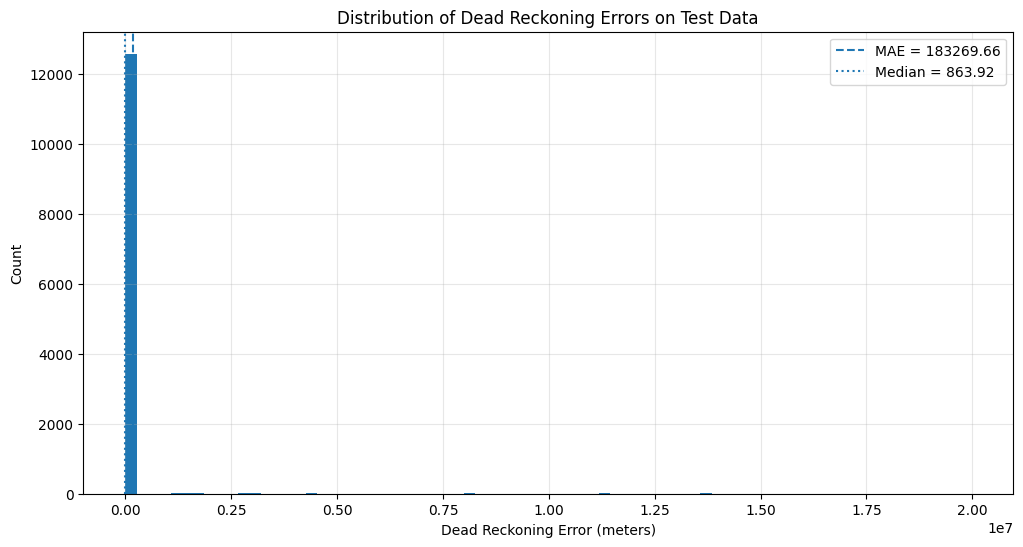

In [11]:
plt.figure(figsize=(12, 6))
plt.hist(dr_pairs["dr_error_m"], bins=75)
plt.axvline(mae_m, linestyle="--", label=f"MAE = {mae_m:.2f}")
plt.axvline(median_m, linestyle=":", label=f"Median = {median_m:.2f}")
plt.xlabel("Dead Reckoning Error (meters)")
plt.ylabel("Count")
plt.title("Distribution of Dead Reckoning Errors on Test Data")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

=== DR ERROR DISTRIBUTION SUMMARY ===
Q1: 172.32
Median: 863.92
Q3: 3503.40
IQR: 3331.08
Lower bound: -4824.29
Upper bound: 8500.02
Number of outliers: 1052
Percent of outliers: 8.19%


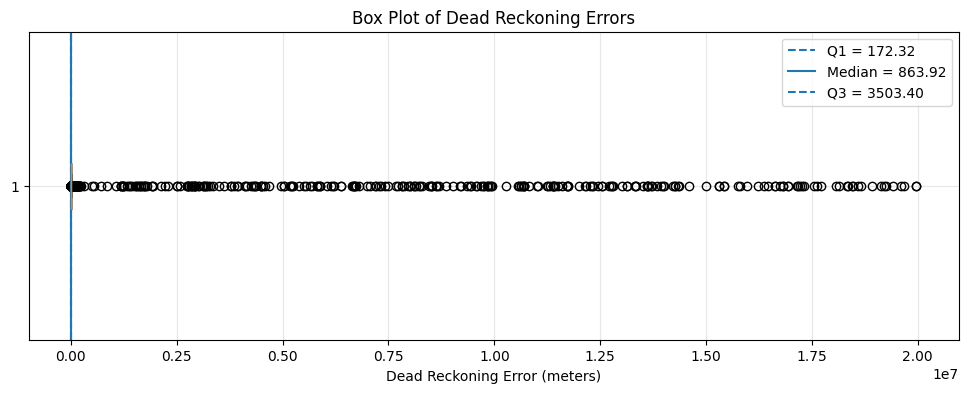

In [12]:
errors = dr_pairs["dr_error_m"].dropna()

q1 = errors.quantile(0.25)
median = errors.quantile(0.50)
q3 = errors.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = errors[(errors < lower_bound) | (errors > upper_bound)]
outlier_pct = 100 * len(outliers) / len(errors)

print("=== DR ERROR DISTRIBUTION SUMMARY ===")
print(f"Q1: {q1:.2f}")
print(f"Median: {median:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")
print(f"Number of outliers: {len(outliers)}")
print(f"Percent of outliers: {outlier_pct:.2f}%")

plt.figure(figsize=(12, 4))
plt.boxplot(errors, vert=False)
plt.axvline(q1, linestyle="--", label=f"Q1 = {q1:.2f}")
plt.axvline(median, linestyle="-", label=f"Median = {median:.2f}")
plt.axvline(q3, linestyle="--", label=f"Q3 = {q3:.2f}")
plt.xlabel("Dead Reckoning Error (meters)")
plt.title("Box Plot of Dead Reckoning Errors")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
OUTPUT_DIR = PROJECT_ROOT / "experiments" / "analysis_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

dr_results_path = OUTPUT_DIR / "dead_reckoning_test_results.csv"

dr_pairs.to_csv(dr_results_path, index=False)

print("Saved:", dr_results_path)

Saved: /home/jacobhardy/capstone/experiments/analysis_outputs/dead_reckoning_test_results.csv


In [14]:
dr_summary = pd.DataFrame([{
    "num_pairs": len(dr_pairs),
    "rmse_m": rmse_m,
    "mae_m": mae_m,
    "median_m": median_m,
    "p95_m": p95_m,
    "q1_m": float(q1),
    "q3_m": float(q3),
    "iqr_m": float(iqr),
    "outlier_count": int(len(outliers)),
    "outlier_percent": float(outlier_pct),
}])

dr_summary_path = OUTPUT_DIR / "dead_reckoning_test_summary.csv"
dr_summary.to_csv(dr_summary_path, index=False)

print("Saved:", dr_summary_path)
dr_summary

Saved: /home/jacobhardy/capstone/experiments/analysis_outputs/dead_reckoning_test_summary.csv


,num_pairs,rmse_m,mae_m,median_m,p95_m,q1_m,q3_m,iqr_m,outlier_count,outlier_percent
0,12841,1.477277e+06,183269.663575,863.916754,11336.656906,172.323208,3503.401971,3331.078763,1052,8.192508
